# Simulation-Based Inference

In [ ]:
# ! pip install jax jaxlib numpyro corner torch astropy

In [89]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from tqdm import tqdm
import corner

%matplotlib inline
%config InlineBackend.figure_format='retina'

jax.config.update("jax_enable_x64", True)

color_default = "firebrick"

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 12,
    }
)

## 1. The Simulator

We simulate maps of point sources on the sky. Each source has a flux $S_i$ and position $\mathbf{r}_i$. The source-count distribution follows a power law:

$$\frac{dN}{dS} = A \cdot S^n$$

Parameters of interest: $\theta = (A, n)$.

In [ ]:
def draw_powerlaw_flux(n_sources, s_min, s_max, exp_b):
    """Draw fluxes from a truncated power law."""
    u = np.random.uniform(0, 1, size=n_sources)
    s_low = s_min ** (exp_b + 1)
    s_high = s_max ** (exp_b + 1)
    return (s_low + (s_high - s_low) * u) ** (1.0 / (exp_b + 1.0))


def simulate_sources(amp_b, exp_b, s_min=0.5, s_max=50.0, box_size=1.0, resolution=64, sigma_psf=0.01):
    """Simulate a map of point sources from a power law dN/dS = A * S^n.

    Returns (fluxes, positions, counts) where counts is a resolution x resolution image.
    """
    # Number of sources (Poisson draw)
    n_sources = np.random.poisson(max(0, -amp_b * (s_min ** (exp_b - 1)) / (exp_b - 1)))

    if n_sources == 0:
        return np.array([]), np.zeros((0, 2)), np.zeros((resolution, resolution))

    # Fluxes and positions (random draws)
    fluxes = draw_powerlaw_flux(n_sources, s_min, s_max, exp_b)
    positions = np.random.uniform(0.0, box_size, size=(n_sources, 2))

    # Bin into pixels and convolve with PSF
    bins = np.linspace(0, box_size, resolution + 1)
    pixel_size = box_size / resolution
    kernel = Gaussian2DKernel(x_stddev=sigma_psf / pixel_size)
    mu_signal = binned_statistic_2d(
        x=positions[:, 0], y=positions[:, 1], values=fluxes, statistic="sum", bins=bins
    ).statistic

    # Poisson realization
    counts = np.random.poisson(np.clip(convolve(mu_signal, kernel), 0, None))
    return fluxes, positions, counts

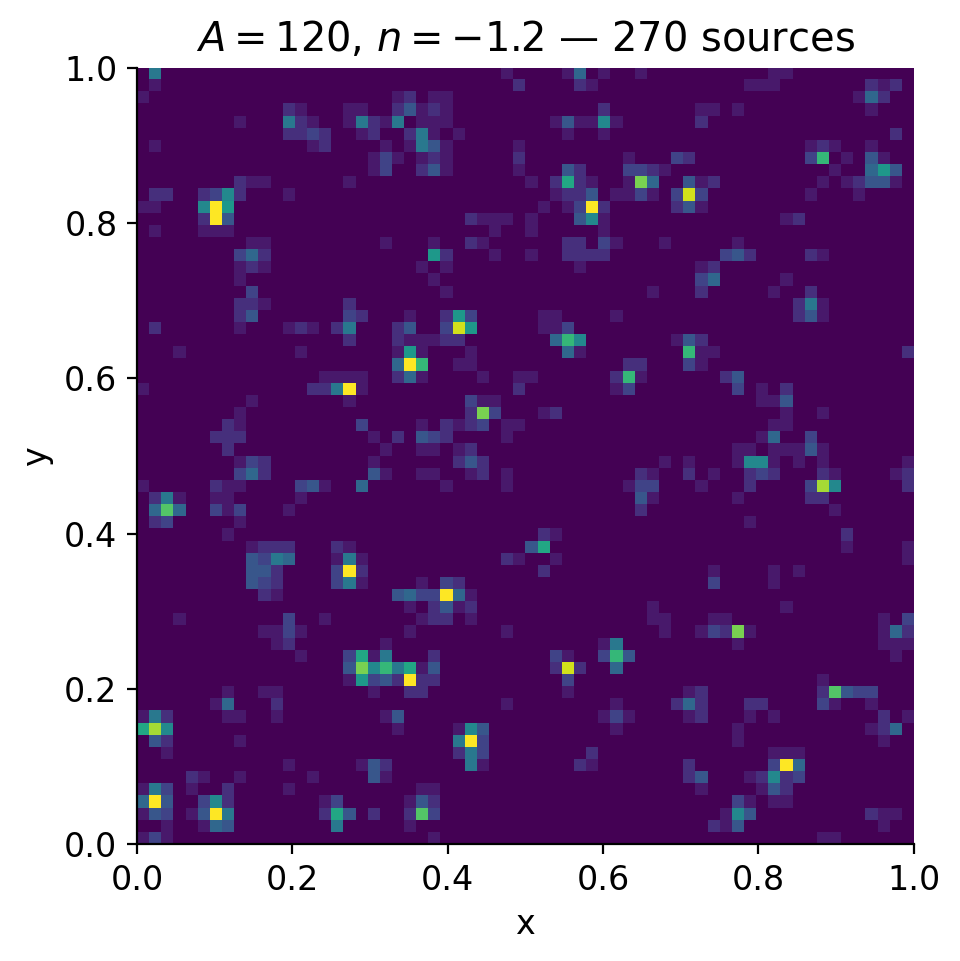

In [ ]:
# Visualize a single realization
np.random.seed(32)
fluxes, positions, counts = simulate_sources(amp_b=120.0, exp_b=-1.2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(counts, cmap="viridis", origin="lower", vmin=0, vmax=15, extent=[0, 1, 0, 1], interpolation="nearest")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"$A = 120$, $n = -1.2$ — {len(fluxes)} sources")
plt.tight_layout()

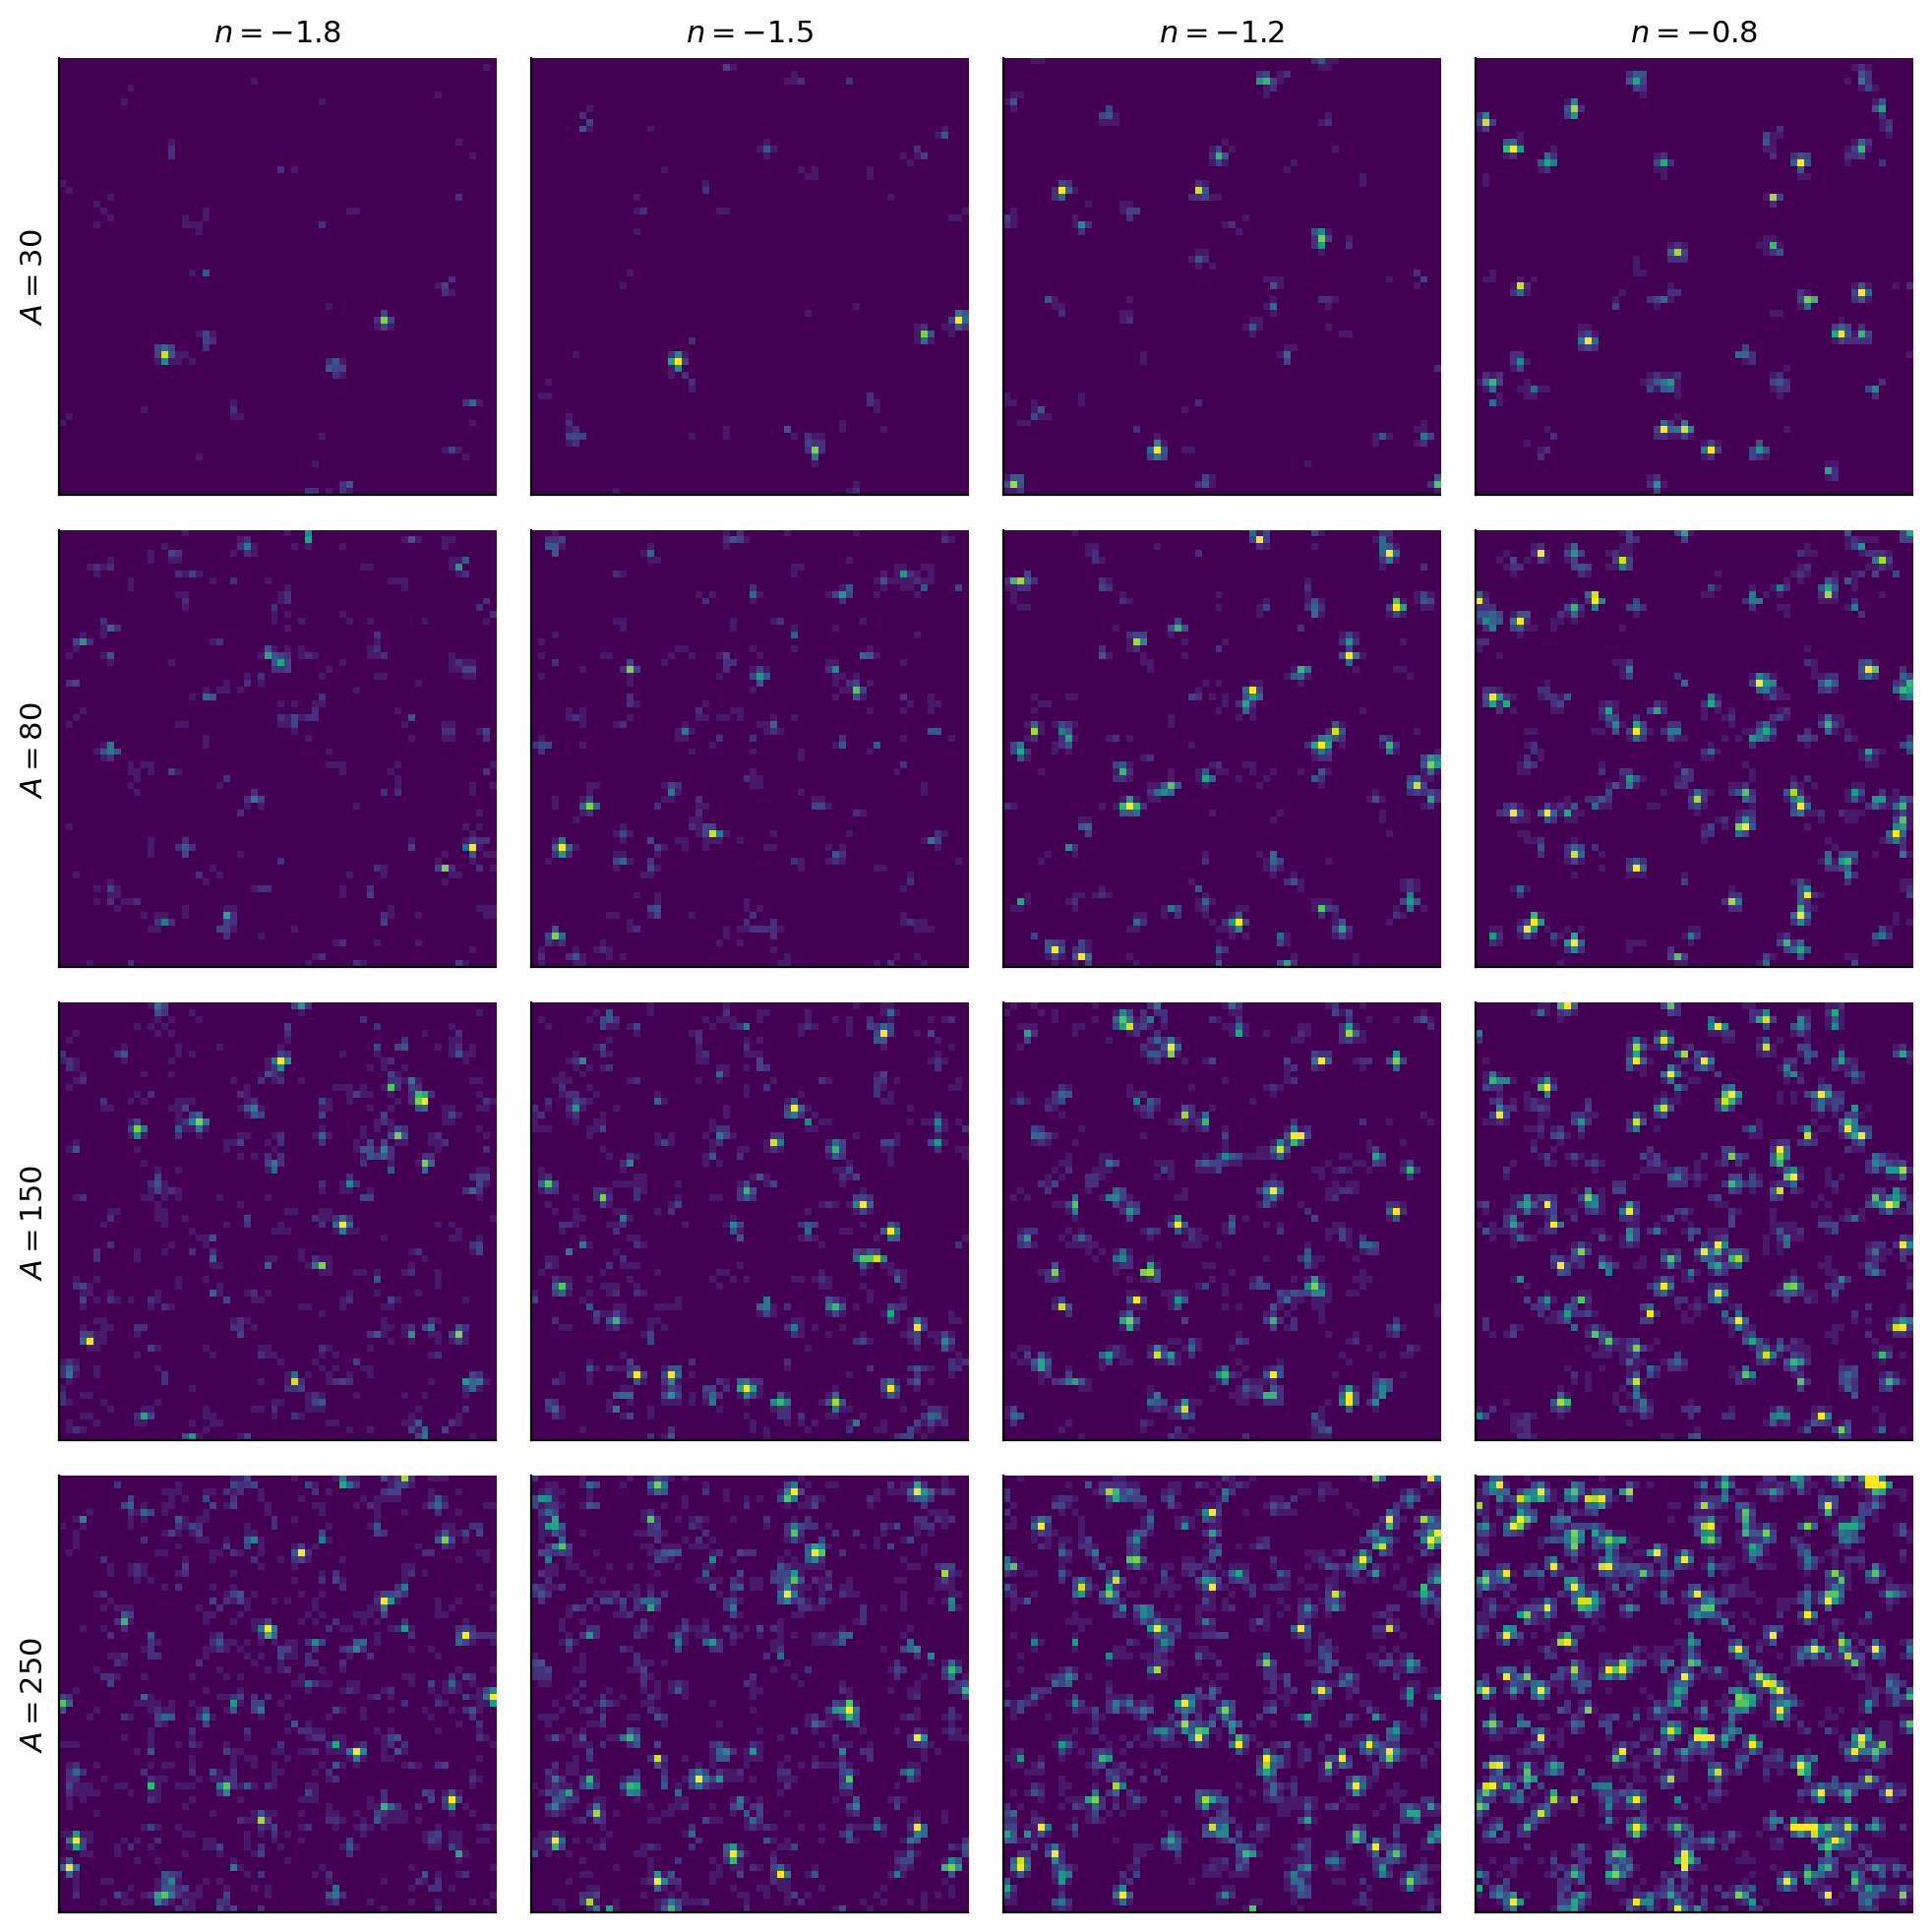

In [ ]:
# Grid showing how maps change with (A, n)
np.random.seed(12)
amp_bs = [30, 80, 150, 250]
exp_bs = [-1.8, -1.5, -1.2, -0.8]

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, amp in enumerate(amp_bs):
    for j, exp in enumerate(exp_bs):
        _, _, c = simulate_sources(amp_b=amp, exp_b=exp)
        axes[i, j].imshow(c, cmap="viridis", vmin=0, vmax=15, origin="lower")
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(f"$n = {exp}$", fontsize=11)
        if j == 0:
            axes[i, j].set_ylabel(f"$A = {amp}$", fontsize=11)
plt.tight_layout()

## 2. Approximate Bayesian Computation

We can't write down $p(x \mid \theta)$ anymore, but we can simulate. Let's try approximate Bayesian computation with a histogram of pixel intensities as summary statistics.

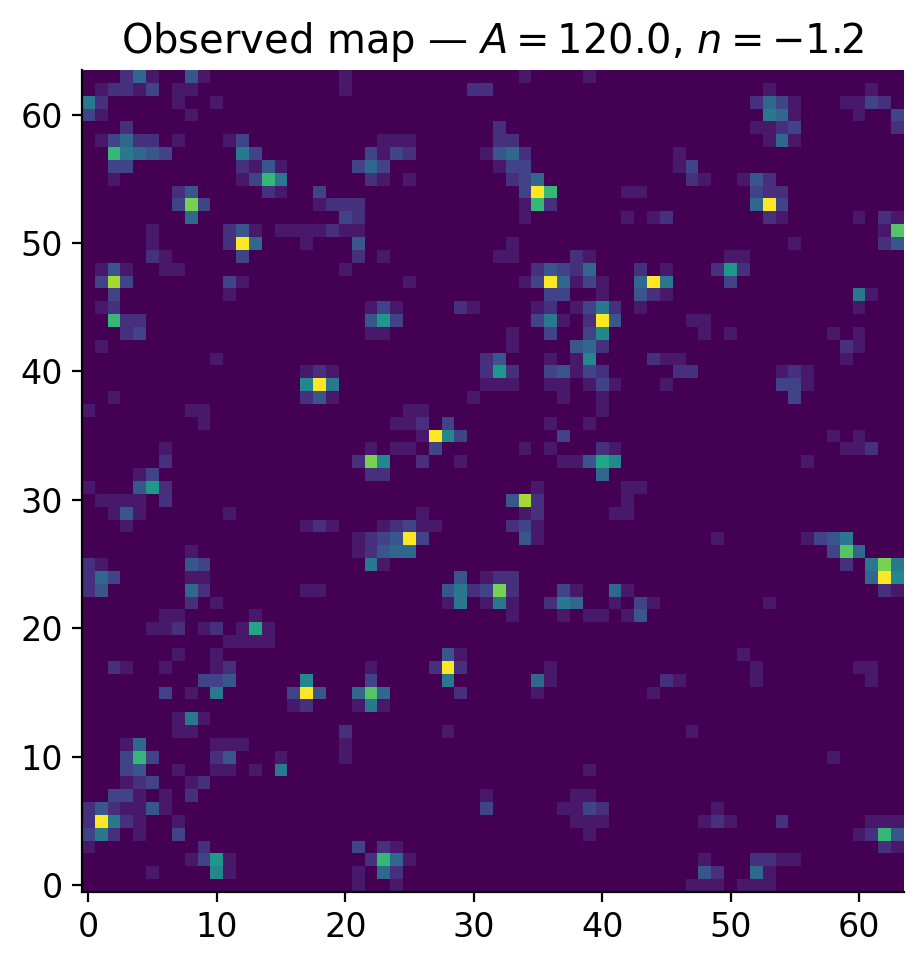

In [ ]:
# Generate the "observed" data for the full model
np.random.seed(42)
theta_true = np.array([120.0, -1.2])
_, _, x_obs_full = simulate_sources(*theta_true)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(x_obs_full, cmap="viridis", origin="lower", vmin=0, vmax=15)
ax.set_title(f"Observed map — $A = {theta_true[0]}$, $n = {theta_true[1]}$")
plt.tight_layout()

In [ ]:
def summary_stats(x, n_bins=15):
    """Summary statistics: histogram of pixel intensities."""
    hist, _ = np.histogram(x.flatten(), bins=n_bins, range=(0, 15), density=True)
    return hist


def abc(x_obs, eps_thresh, n_samples=2000, amp_range=(10.0, 300.0), exp_range=(-2.5, -0.5)):
    """ABC rejection sampling for the point source model."""
    s_obs = summary_stats(x_obs)
    samples = []
    n_tried = 0
    pbar = tqdm(total=n_samples, desc="ABC")

    while len(samples) < n_samples:
        # Prior draw
        A = np.random.uniform(*amp_range)
        n = np.random.uniform(*exp_range)

        # Simulate
        _, _, x_sim = simulate_sources(A, n)
        s_sim = summary_stats(x_sim)

        # Distance
        dist_val = np.sqrt(np.sum((s_sim - s_obs) ** 2))
        n_tried += 1

        if dist_val < eps_thresh:
            samples.append([A, n])
            pbar.update(1)
            pbar.set_postfix(acc=f"{len(samples) / n_tried:.3f}")

    pbar.close()
    return np.array(samples)

In [ ]:
# Run ABC
abc_samples = abc(x_obs_full, eps_thresh=0.05, n_samples=2000)

ABC: 100%|██████████| 2000/2000 [00:08<00:00, 242.11it/s, acc=0.237]


Text(0.5, 1.02, 'ABC posterior (histogram summary)')

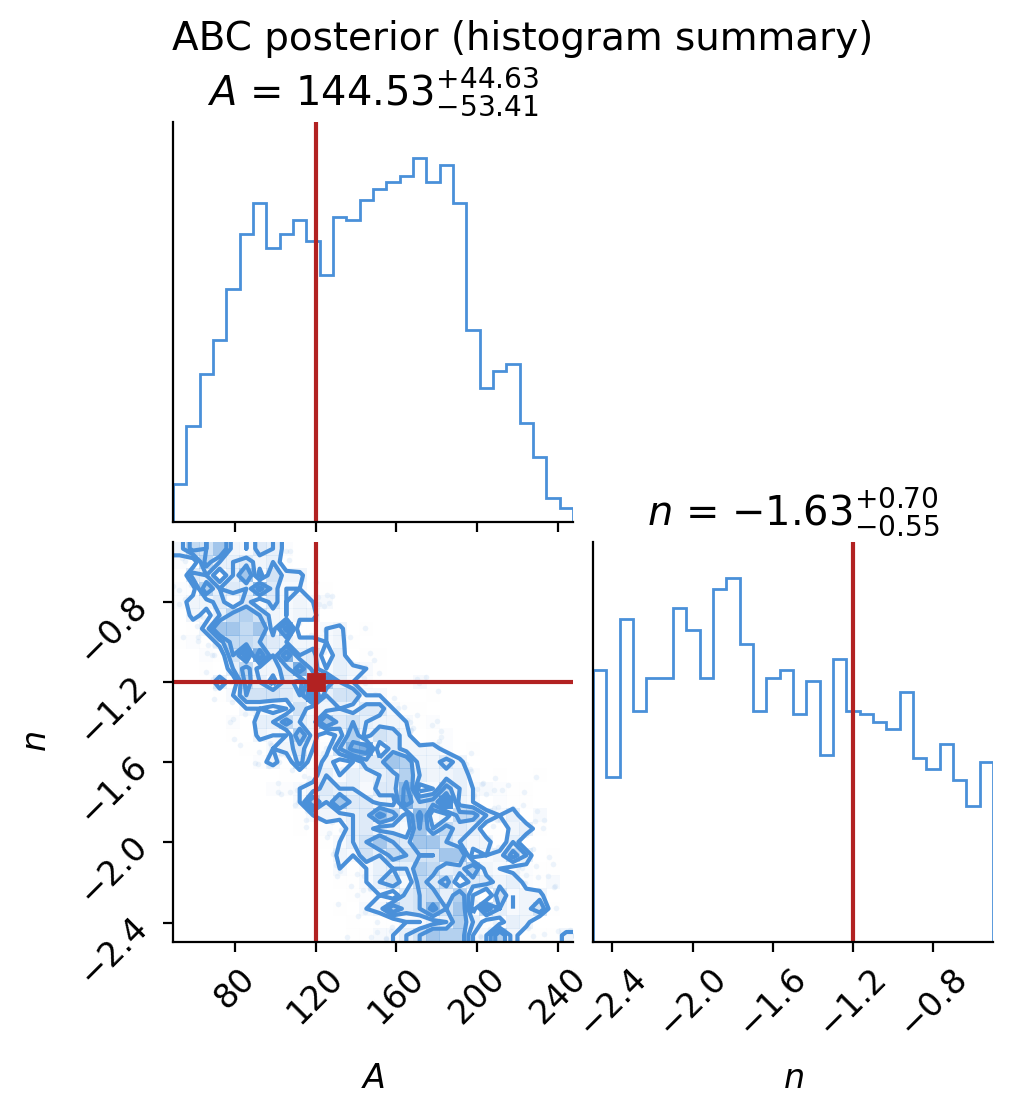

In [ ]:
fig = corner.corner(
    abc_samples,
    labels=[r"$A$", r"$n$"],
    truths=theta_true,
    truth_color=color_default,
    show_titles=True,
    color="#4A90D9",
    bins=30,
)
fig.suptitle("ABC posterior (histogram summary)", y=1.02, fontsize=14)

## 4. Neural Posterior Estimation

Instead of throwing away most simulations (ABC), we use all of them to train a neural network that maps observations directly to posteriors.

Architecture: CNN featurizer → Gaussian density estimator.

In [ ]:
import flax.linen as nn
import optax

### 4.1 Generate training data

In [ ]:
n_train = 5_000
np.random.seed(0)

theta_train = np.column_stack(
    [
        np.random.uniform(10.0, 300.0, n_train),  # A
        np.random.uniform(-2.5, -0.5, n_train),  # n
    ]
)

x_train = np.array([simulate_sources(t[0], t[1])[2] for t in tqdm(theta_train)])
print(f"Training data: {x_train.shape}")

100%|██████████| 5000/5000 [00:02<00:00, 1888.07it/s]

Training data: (5000, 64, 64)


In [ ]:
# Convert to JAX arrays and normalize
theta_j = jnp.array(theta_train, dtype=jnp.float32)
x_j = jnp.array(x_train, dtype=jnp.float32)

x_mean, x_std = x_j.mean(0), jnp.clip(x_j.std(0), 1e-6)
theta_mean, theta_std = theta_j.mean(0), theta_j.std(0)

x_j = (x_j - x_mean) / x_std
theta_j = (theta_j - theta_mean) / theta_std

### 4.2 Define the model

CNN compresses the 64×64 map into features. A small MLP head outputs the mean and log-std of a diagonal Gaussian over $\theta$.

In [ ]:
class NPE(nn.Module):
    """Neural posterior estimation: CNN featurizer + Gaussian density head."""

    @nn.compact
    def __call__(self, x):
        # x: (B, 64, 64) -> (B, 64, 64, 1) channels-last for Flax Conv
        x = x[..., None]

        # CNN featurizer
        x = nn.max_pool(nn.gelu(nn.Conv(16, (3, 3), padding="SAME")(x)), (2, 2), strides=(2, 2))
        x = nn.max_pool(nn.gelu(nn.Conv(32, (3, 3), padding="SAME")(x)), (2, 2), strides=(2, 2))
        x = nn.max_pool(nn.gelu(nn.Conv(64, (3, 3), padding="SAME")(x)), (2, 2), strides=(2, 2))
        x = x.reshape(x.shape[0], -1)  # (B, 64*8*8)
        x = nn.gelu(nn.Dense(128)(x))

        # Gaussian head
        mu = nn.Dense(2)(x)
        log_sigma = nn.Dense(2)(x)
        return mu, log_sigma


def npe_log_prob(params, model, x, theta):
    """Diagonal Gaussian log-probability."""
    mu, log_sigma = model.apply(params, x)
    sigma = jnp.exp(log_sigma)
    return jnp.sum(
        -0.5 * ((theta - mu) / sigma) ** 2 - log_sigma - 0.5 * jnp.log(2 * jnp.pi),
        axis=-1,
    )


def npe_sample(params, model, x, key, n_samples=10_000):
    """Sample from the approximate Gaussian posterior."""
    mu, log_sigma = model.apply(params, x)
    sigma = jnp.exp(log_sigma)
    eps = jax.random.normal(key, (n_samples, 2))
    return mu + sigma * eps


# Initialize
model = NPE()
key = jax.random.PRNGKey(0)
params = model.init(key, jnp.ones((1, 64, 64)))

# Check shapes
mu, log_sigma = model.apply(params, x_j[:2])
print(f"mu: {mu.shape}, log_sigma: {log_sigma.shape}")

mu: (2, 2), log_sigma: (2, 2)


### 4.3 Train

In [ ]:
@jax.jit
def train_step(params, opt_state, x_batch, theta_batch):
    def loss_fn(params):
        return -jnp.mean(npe_log_prob(params, model, x_batch, theta_batch))

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, opt_state_new = optimizer.update(grads, opt_state, params)
    params_new = optax.apply_updates(params, updates)
    return params_new, opt_state_new, loss


optimizer = optax.adam(3e-4)
opt_state = optimizer.init(params)

batch_size = 64
n_batches = len(x_j) // batch_size
n_epochs = 10
losses = []

for epoch in range(n_epochs):
    # Shuffle
    key, subkey = jax.random.split(key)
    perm = jax.random.permutation(subkey, len(x_j))
    x_shuf, theta_shuf = x_j[perm], theta_j[perm]

    epoch_loss = 0.0
    for i in range(n_batches):
        sl = slice(i * batch_size, (i + 1) * batch_size)
        params, opt_state, loss = train_step(params, opt_state, x_shuf[sl], theta_shuf[sl])
        epoch_loss += float(loss)

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch + 1:3d}: loss = {avg_loss:.3f}")

Epoch   5: loss = -0.101
Epoch  10: loss = -1.024


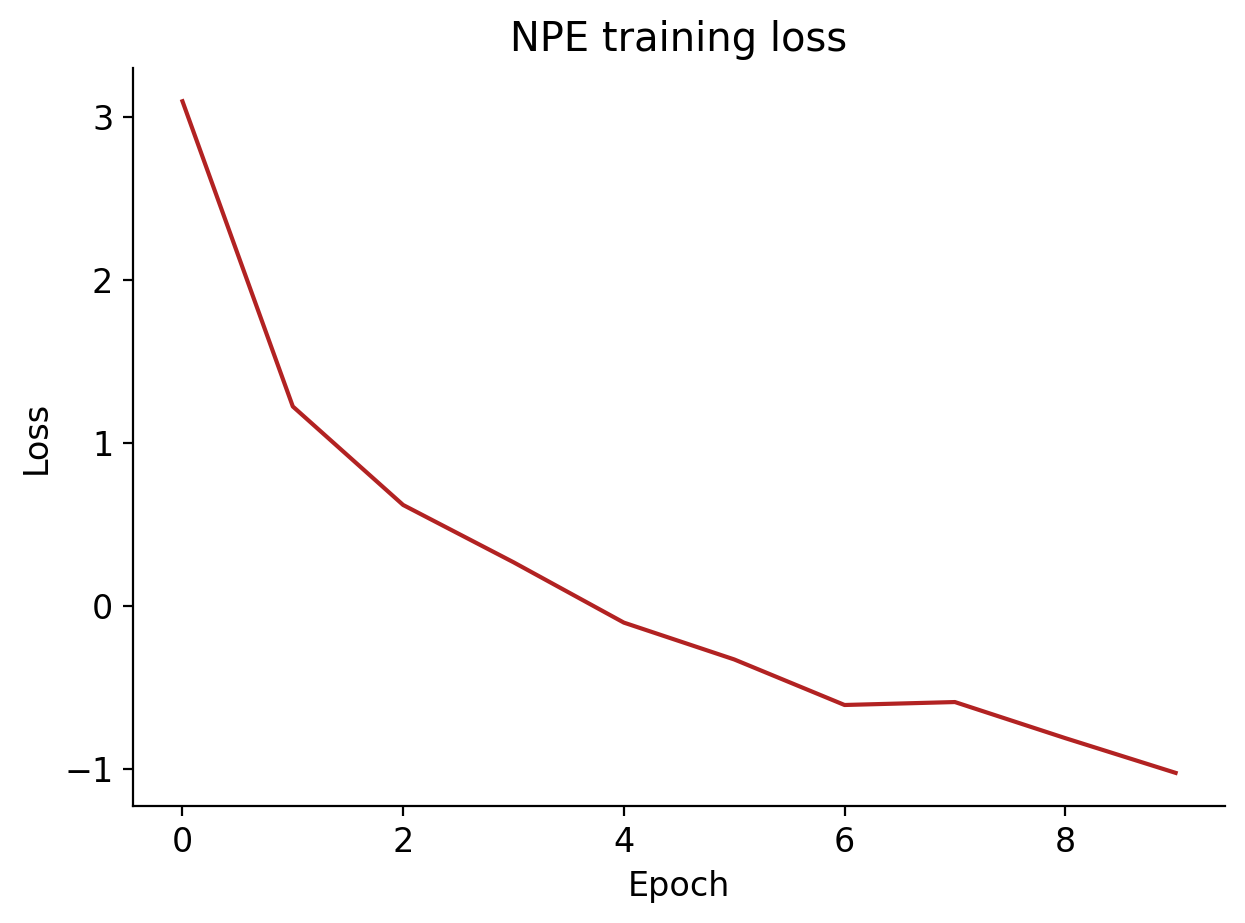

In [ ]:
plt.plot(losses, color=color_default)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NPE training loss")
plt.tight_layout()

### 4.4 Test on the observed data

Text(0.5, 1.02, 'NPE posterior')

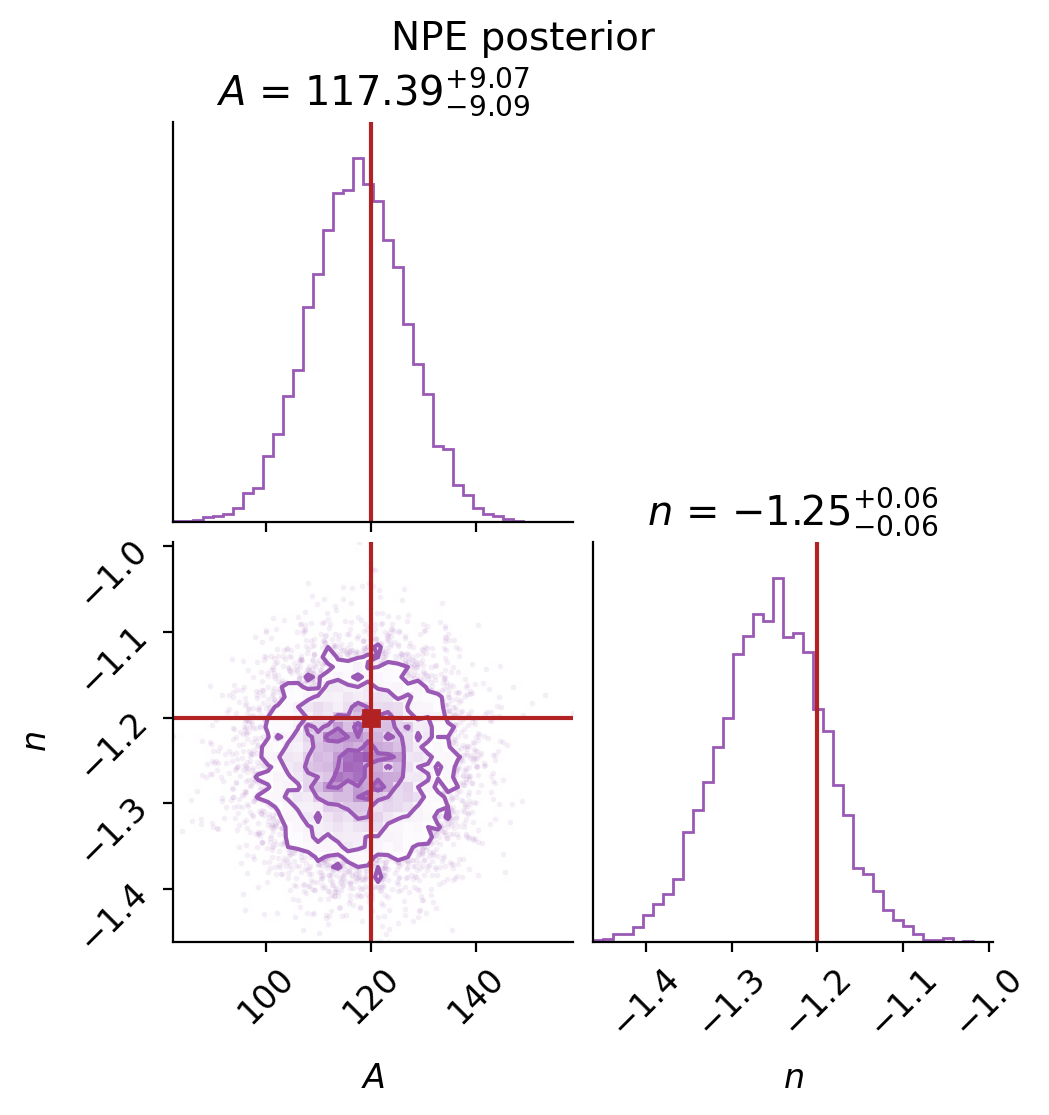

In [ ]:
x_test = (jnp.array(x_obs_full, dtype=jnp.float32) - x_mean) / x_std
npe_samples_norm = npe_sample(params, model, x_test[None], jax.random.PRNGKey(1))
npe_samps = np.array(npe_samples_norm * theta_std + theta_mean)

fig = corner.corner(
    npe_samps,
    labels=[r"$A$", r"$n$"],
    truths=theta_true,
    truth_color=color_default,
    show_titles=True,
    color="#9B59B6",
    bins=40,
)
fig.suptitle("NPE posterior", y=1.02, fontsize=14)

### 4.5 Amortization — instant posteriors for new observations

The whole point of NPE: we trained once, and now we can get posteriors for *any* new observation in a single forward pass. No re-training, no new MCMC chains.

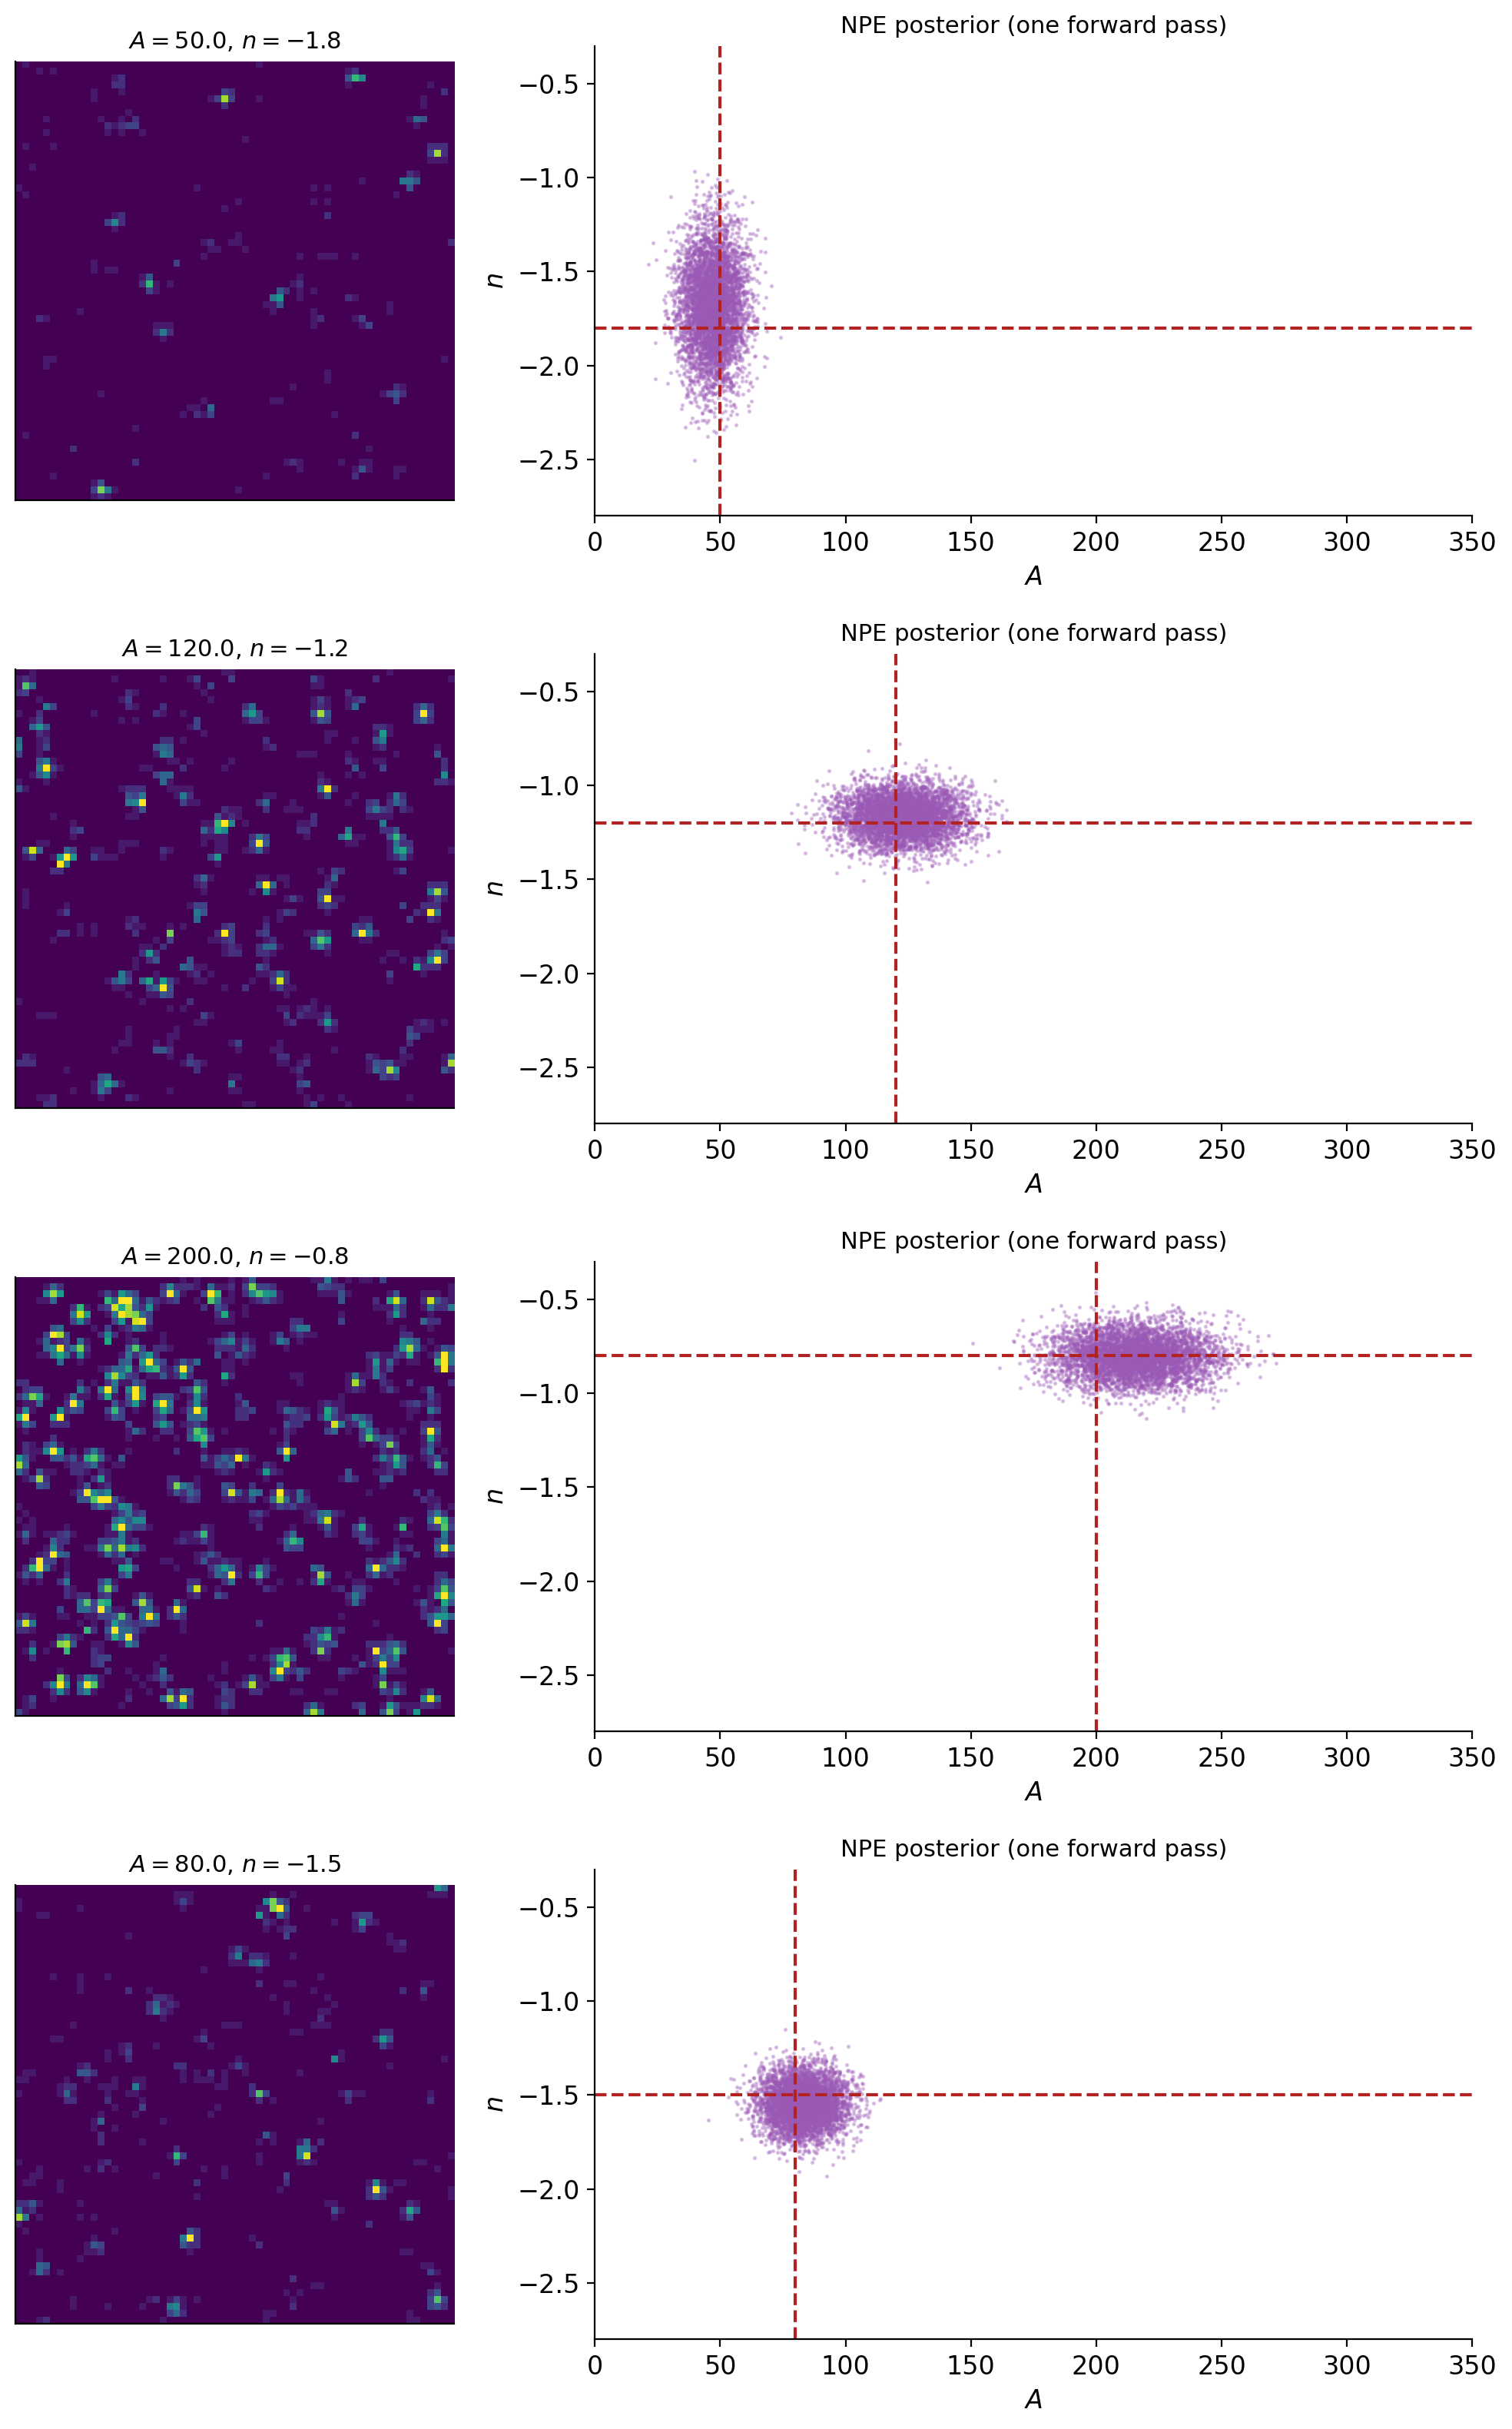

In [ ]:
# Generate several test observations with different true parameters
test_cases = [
    (50.0, -1.8),
    (120.0, -1.2),
    (200.0, -0.8),
    (80.0, -1.5),
]

fig, axes = plt.subplots(len(test_cases), 2, figsize=(10, 4 * len(test_cases)), gridspec_kw={"width_ratios": [1, 2]})

for i, (A_test, n_test) in enumerate(test_cases):
    np.random.seed(100 + i)
    _, _, x_test_map = simulate_sources(A_test, n_test)

    # Show the map
    axes[i, 0].imshow(x_test_map, cmap="viridis", origin="lower", vmin=0, vmax=15)
    axes[i, 0].set_title(f"$A={A_test}$, $n={n_test}$", fontsize=11)
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

    # NPE posterior — one forward pass
    x_in = (jnp.array(x_test_map, dtype=jnp.float32) - x_mean) / x_std
    samps = npe_sample(params, model, x_in[None], jax.random.PRNGKey(200 + i), n_samples=5000)
    samps = np.array(samps * theta_std + theta_mean)

    axes[i, 1].scatter(samps[:, 0], samps[:, 1], s=1, alpha=0.3, color="#9B59B6")
    axes[i, 1].axvline(A_test, color=color_default, ls="--", lw=1.5)
    axes[i, 1].axhline(n_test, color=color_default, ls="--", lw=1.5)
    axes[i, 1].set_xlabel("$A$")
    axes[i, 1].set_ylabel("$n$")
    axes[i, 1].set_xlim(0, 350)
    axes[i, 1].set_ylim(-2.8, -0.3)
    axes[i, 1].set_title("NPE posterior (one forward pass)", fontsize=11)

plt.tight_layout()